In [ ]:
import torch
import soundfile as sf
import torchaudio
import matplotlib.pyplot as plt
from nnAudio.features.gammatone import Gammatonegram

# 1. 파일 경로 설정 (실제 가지고 계신 데이터셋의 wav 파일 경로로 변경하세요)
# 예: DCASE STARSS 데이터셋의 임의의 파일
audio_path = 'C:/data/2024DCASE_data/mic_dev/dev-test-sony/fold4_room23_mix001.wav' 

# 프론트엔드 파라미터 세팅 (기존 코드와 동일)
sr = 24000
n_bins = 64
hop_length = 480
win_length = hop_length * 2
n_fft = 2 ** (win_length - 1).bit_length()
fmax = sr //2

# 2. 오디오 로드 및 전처리
waveform, sample_rate = sf.read(audio_path)
waveform = torch.from_numpy(waveform).transpose(0, 1).float()
# SELD용 4채널(FOA/MIC) 데이터라면, 시각화를 위해 첫 번째 채널만 가져옵니다.
if waveform.shape[0] > 1:
    waveform = waveform[0:1, :]
# 샘플링 레이트 맞추기
if sample_rate != sr:
    waveform = torchaudio.functional.resample(waveform, sample_rate, sr)


# 3. 특징 추출기 초기화 (학습 옵션은 반드시 끄기!)
mel_extractor = torchaudio.transforms.MelSpectrogram(
    sample_rate=sr, n_fft=n_fft, hop_length=hop_length, 
    win_length=win_length, n_mels=n_bins, window_fn=torch.hann_window
)

gt_extractor = Gammatonegram(
    sr=sr, n_fft=n_fft, n_bins=n_bins, hop_length=hop_length, 
    window='hann', fmax=fmax, win_length=win_length, 
    trainable_STFT=False, trainable_bins=False
)

# 4. 특징 추출 및 스케일(Log) 변환
# --- [Log-Mel] ---
mel_spec = mel_extractor(waveform)
mel_log = 10.0 * torch.log10(mel_spec.clamp_min(1e-10))

# --- [Log-Gammatone] ---
gt_spec = gt_extractor(waveform)
# 지난번 해결책이었던 1000배 스케일 업 적용
gt_spec_scaled = gt_spec 
gt_log = 10.0 * torch.log10(gt_spec_scaled.clamp_min(1e-10))
# [1, n_bins, Frames] -> [n_bins, Frames] 로 차원 축소
mel_img = mel_log[0].numpy()
gt_img = gt_log[0].numpy()

# 5. 시각화
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# 색상 맵(Color map)의 범위를 동일하게 맞춰야 정확한 비교가 가능합니다.
vmin = min(mel_img.min(), gt_img.min())
vmax = max(mel_img.max(), gt_img.max())

# Mel Spectrogram
im1 = axes[0].imshow(mel_img, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
axes[0].set_title('Log-Mel Spectrogram (torchaudio)', fontsize=14)
axes[0].set_ylabel('Mel Bins')

# Gammatone Spectrogram
im2 = axes[1].imshow(gt_img, aspect='auto', origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
axes[1].set_title('Scaled Log-Gammatone Spectrogram (nnAudio)', fontsize=14)
axes[1].set_ylabel('Gammatone Bins')
axes[1].set_xlabel('Frames (Time)')

# 컬러바 추가 (에너지 크기 확인용)
fig.colorbar(im1, ax=axes[0], format='%+2.0f dB')
fig.colorbar(im2, ax=axes[1], format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# gt_log: 정규화(Standardization)를 하기 직전, 로그만 씌운 Gammatone 스펙트로그램
# 차원 축소: [1, n_bins, Frames] -> [n_bins, Frames]
data = gt_norm[0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- [방법 1: 히스토그램 (분포와 꼬리 확인)] ---
# 데이터가 어떻게 분포하는지, 극단적으로 큰 값이 있는지 확인합니다.
# 이상치가 적은 픽셀에만 존재할 수 있으므로 y축을 로그 스케일로 봅니다.
axes[0].hist(data.flatten(), bins=100, color='royalblue', alpha=0.7)
axes[0].set_title('1. Histogram of Values (Log Y-scale)')
axes[0].set_yscale('log') 
axes[0].set_xlabel('Value (dB)')
axes[0].set_ylabel('Pixel Count (Log)')

# --- [방법 2: 시간축(Frame) 최댓값 플롯 (패딩 스파이크 확인)] ---
# 각 시간 프레임별로 가장 큰 에너지를 가진 값을 선 그래프로 그립니다.
max_over_time = data.max(axis=0) 
axes[1].plot(max_over_time, color='crimson')
axes[1].set_title('2. Max Value over Time (Frames)')
axes[1].set_xlabel('Frames (Time)')
axes[1].set_ylabel('Max dB')

# --- [방법 3: 주파수축(Bin) 최댓값 플롯 (특정 대역 쏠림 확인)] ---
# 각 주파수 빈(Bin)별로 전체 시간 중 가장 큰 값을 선 그래프로 그립니다.
max_over_freq = data.max(axis=1)
axes[2].plot(max_over_freq, color='seagreen')
axes[2].set_title('3. Max Value over Frequency Bins')
axes[2].set_xlabel('Gammatone Bins (Low -> High)')
axes[2].set_ylabel('Max dB')

plt.tight_layout()
plt.show()

# --- [보너스 방법: 상위 1% 쳐내고 스펙트로그램 그리기 (Percentile Clipping)] ---
# 진짜 이상치 때문에 그림이 망가진 건지 확인하는 결정적 방법입니다.
vmax_99 = np.percentile(data, 99.5) # 상위 0.5%의 값을 최댓값으로 강제 지정
vmin_01 = np.percentile(data, 1.0)  # 하위 1%의 값을 최솟값으로 강제 지정

plt.figure(figsize=(10, 4))
plt.imshow(data, aspect='auto', origin='lower', cmap='magma', vmin=vmin_01, vmax=vmax_99)
plt.title(f'Clipped Spectrogram (vmax={vmax_99:.1f} dB, 99.5th percentile)')
plt.colorbar(format='%+2.0f dB')
plt.ylabel('Gammatone Bins')
plt.xlabel('Frames')
plt.show()

print(f"전체 절댓값 Max: {data.max():.2f}")
print(f"상위 0.5% Max: {vmax_99:.2f}")

In [ ]:
import re
import matplotlib.pyplot as plt
from pathlib import Path

log_text = r"""
INFO: 03/26/2026 01:11:20: epoch: 1, step: 100/100000, lr:0.000020, train_loss:0.0783
INFO: 03/26/2026 01:11:49: epoch: 1, step: 200/100000, lr:0.000030, train_loss:0.0753
INFO: 03/26/2026 01:12:23: epoch: 1, step: 273/100000, train_time:78.93, test_time:6.03, average_train_loss:0.0783, average_test_loss:0.0512

INFO: 03/26/2026 10:08:40: save checkpoint: ./output/my_experiment13/checkpoints\checkpoint_epoch366_step99918.pth
INFO: 03/26/2026 10:09:02: epoch: 367, step: 100000/100000, lr:0.000050, train_loss:0.0001
INFO: 03/26/2026 10:09:20: epoch: 367, step: 100000/100000, train_time:21.61, test_time:5.65, average_train_loss:0.0002, average_test_loss:0.1268
INFO: 03/26/2026 10:09:20: ER/F/LE/LR/SELD: 0.6602/0.3432/20.7384/0.6817/0.4376
INFO: 03/26/2026 10:09:20: save checkpoint: ./output/my_experiment13/checkpoints\checkpoint_epoch367_step100000.pth
"""

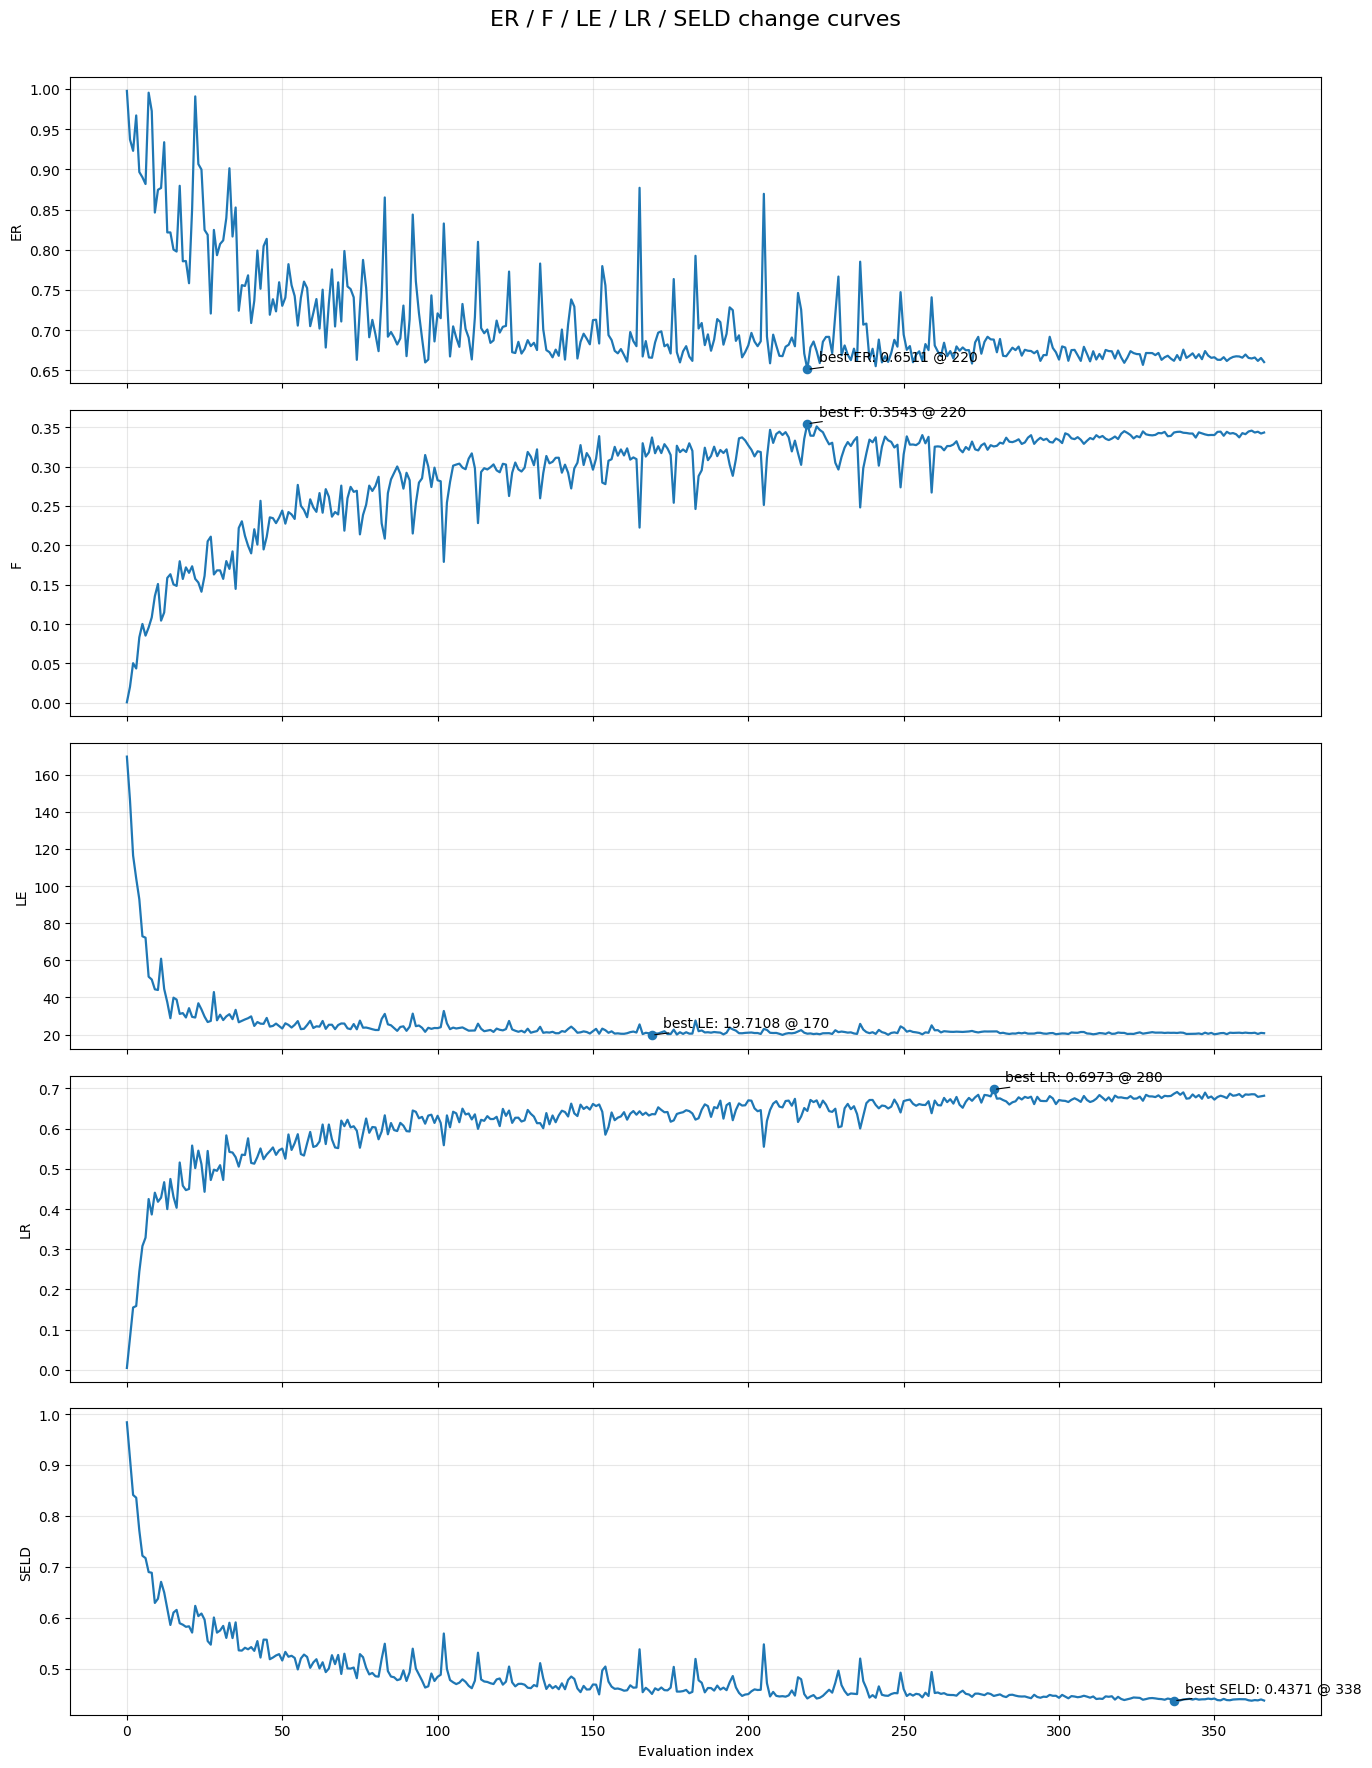

In [12]:
import re
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# 1) regex
# -------------------------------------------------
epoch_pattern = re.compile(r"epoch:\s*(\d+)")
metric_pattern = re.compile(
    r"ER/F/LE/LR/SELD:\s*"
    r"([0-9]+(?:\.[0-9]+)?)\s*/\s*"
    r"([0-9]+(?:\.[0-9]+)?)\s*/\s*"
    r"([0-9]+(?:\.[0-9]+)?)\s*/\s*"
    r"([0-9]+(?:\.[0-9]+)?)\s*/\s*"
    r"([0-9]+(?:\.[0-9]+)?)"
)

epochs = []
ER_list, F_list, LE_list, LR_list, SELD_list = [], [], [], [], []
current_epoch = None

for line in log_text.splitlines():
    epoch_match = epoch_pattern.search(line)
    if epoch_match:
        current_epoch = int(epoch_match.group(1))

    metric_match = metric_pattern.search(line)
    if metric_match and current_epoch is not None:
        er, f1, le, lr, seld = map(float, metric_match.groups())

        epochs.append(current_epoch)
        ER_list.append(er)
        F_list.append(f1)
        LE_list.append(le)
        LR_list.append(lr)
        SELD_list.append(seld)
        
# 3) plotting 함수
# -------------------------------------------------
def plot_metric_curves_like_example(epochs, ER, F, LE, LR, SELD, save_path=None):
    """
    x축은 evaluation index
    annotation은 best value와 epoch를 표시
    """

    # x축: evaluation index
    x = np.arange(len(epochs))

    fig, axes = plt.subplots(5, 1, figsize=(14, 18), sharex=True)
    fig.suptitle("ER / F / LE / LR / SELD change curves", fontsize=16)

    metric_configs = [
        ("ER", ER, "min"),
        ("F", F, "max"),
        ("LE", LE, "min"),
        ("LR", LR, "max"),
        ("SELD", SELD, "min"),
    ]

    for ax, (name, values, mode) in zip(axes, metric_configs):
        values = np.array(values, dtype=float)

        ax.plot(x, values, linewidth=1.6)
        ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)

        # best index 찾기
        if mode == "min":
            best_idx = np.argmin(values)
        else:
            best_idx = np.argmax(values)

        best_x = x[best_idx]
        best_y = values[best_idx]
        best_epoch = epochs[best_idx]

        # best point 표시
        ax.scatter(best_x, best_y, s=35, zorder=3)

        # annotation 위치를 살짝 옆으로
        x_offset = max(3, len(x) * 0.01)
        y_span = values.max() - values.min()
        if y_span == 0:
            y_span = 1.0

        ax.annotate(
            f"best {name}: {best_y:.4f} @ {best_epoch}",
            xy=(best_x, best_y),
            xytext=(best_x + x_offset, best_y + y_span * 0.03),
            fontsize=10,
            arrowprops=dict(arrowstyle="-", lw=0.8)
        )

    axes[-1].set_xlabel("Evaluation index")
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()


# -------------------------------------------------
# 4) 실행
# -------------------------------------------------
plot_metric_curves_like_example(
    epochs=epochs,
    ER=ER_list,
    F=F_list,
    LE=LE_list,
    LR=LR_list,
    SELD=SELD_list,
    save_path="metric_curves.png"   # 저장 원하면 유지, 아니면 None
)